# CSCI E-89 Deep Learning
## Assignment 04

**Student:** Carlos Fernandez  
**Notebook:** e89_Fernandez_Carlos_HW02  
**Environment:** Windows, Python 3.10, Pytorch, and Google Collab

In [3]:
# Libraries installation

# %pip install torch torchvision scikit-learn matplotlib pillow pandas

from pathlib import Path
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay,
)

SEED = 42

def set_seed(seed=SEED):
    """Reset every random-number generator we use, so runs are repeatable and comparable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
torch.set_num_threads(4)  # Avoid excessive CPU thread overhead for these small models.

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')

DATA_DIR = Path('data')          # Change to Path('../data') if flower_photos is already there.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('PyTorch:', torch.__version__, '| torchvision:', __import__('torchvision').__version__)
print('Device:', device)

PyTorch: 2.14.0+cpu | torchvision: 0.29.0+cpu
Device: cpu


## 1.1 Load MNIST with `torchvision.datasets.MNIST`

datasets.MNIST` downloads the data the first time and reuses it afterwards. `train=True` returns the 60,000 official training images; `train=False` returns the 10,000 official test images.

The `ToTensor()` transform does two things:
- converts pixel values from integers 0–255 to floats 0–1 (small, consistently scaled inputs help training);
- rearranges each image to PyTorch's **(channels, height, width)** order. MNIST is grayscale, so each image becomes `(1, 28, 28)`.

In the sklearn notebook we added the channel dimension with `unsqueeze(1)` and divided by 16 ourselves. `ToTensor()` now does both.

Labels are integers 0–9. `CrossEntropyLoss` expects exactly this kind of integer class label.

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 778kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.12MB/s]


Training images (official): 60000
Test images (official):     10000
Raw storage shape: (60000, 28, 28) | dtype: torch.uint8
One transformed image: (1, 28, 28) | pixel range: 0.0 to 1.0 | label: 5


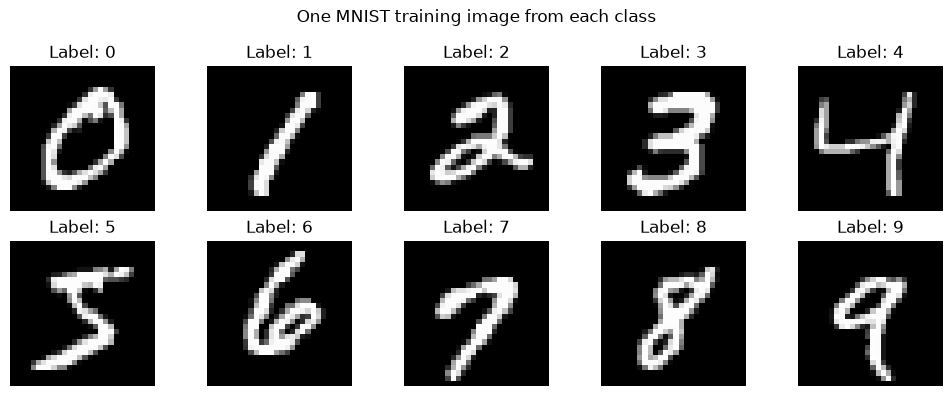

In [5]:
mnist_transform = transforms.ToTensor()   # 0–255 integers -> 0–1 floats, shape (1, 28, 28)

mnist_full_train = datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=mnist_transform)
mnist_test       = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=mnist_transform)
mnist_classes = [str(d) for d in range(10)]

print('Training images (official):', len(mnist_full_train))
print('Test images (official):    ', len(mnist_test))
print('Raw storage shape:', tuple(mnist_full_train.data.shape), '| dtype:', mnist_full_train.data.dtype)

example_image, example_label = mnist_full_train[0]
print('One transformed image:', tuple(example_image.shape),
      '| pixel range:', example_image.min().item(), 'to', example_image.max().item(),
      '| label:', example_label)

# Display the first training example of every digit.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = (mnist_full_train.targets == digit).nonzero()[0].item()
    image, label = mnist_full_train[index]
    ax.imshow(image[0], cmap='gray')          # image[0] removes the channel axis for plotting
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('One MNIST training image from each class')
plt.tight_layout()
plt.show()

## 1.2 Create training, validation and test sets and DataLoaders

MNIST already has an official test set of 10,000 images. We keep it untouched until the end. From the 60,000 training images we hold out **10,000 for validation** with `random_split`. A seeded generator makes that split repeatable.

| Split | Images | Used for |
|---|---:|---|
| Training | 50,000 | learning the weights |
| Validation | 10,000 | watching for overfitting and choosing the best epoch |
| Test | 10,000 | one final, unbiased evaluation |

A `DataLoader` serves the data in small groups called **batches**. Only the training loader is shuffled, so the model doesn't learn from a fixed order. Its own seeded generator keeps the shuffling reproducible. Validation and test loaders don't need shuffling.

A CNN batch has shape **(batch, channels, height, width)** = `(128, 1, 28, 28)`.

In [6]:
mnist_train, mnist_val = random_split(
    mnist_full_train, [50_000, 10_000], generator=torch.Generator().manual_seed(SEED)
)

MNIST_BATCH_SIZE = 128
mnist_train_loader = DataLoader(mnist_train, batch_size=MNIST_BATCH_SIZE, shuffle=True,
                                generator=torch.Generator().manual_seed(SEED))
mnist_val_loader  = DataLoader(mnist_val,  batch_size=256, shuffle=False)
mnist_test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)

for name, subset in [('Training', mnist_train), ('Validation', mnist_val), ('Test', mnist_test)]:
    print(f'{name:10s}: {len(subset):6,d} images')

batch_images, batch_labels = next(iter(mnist_train_loader))
print('Image batch shape:', tuple(batch_images.shape))
print('Label batch shape:', tuple(batch_labels.shape), batch_labels.dtype)

Training  : 50,000 images
Validation: 10,000 images
Test      : 10,000 images
Image batch shape: (128, 1, 28, 28)
Label batch shape: (128,) torch.int64


## 1.3 Define a vanilla CNN for 28×28 images

The network has two parts.

**Feature extractor (convolutional blocks).** Each block is Conv2d → ReLU → MaxPool2d.
- A **convolution** slides small learned **filters** (3×3 here) over the image. At every position it multiplies the filter weights by the pixels under them and sums the products (plus a bias) into one number. The result for one filter is a 2D **feature map** that shows where that filter's pattern appears. All positions share the same weights, so a pattern learned in one place is recognized anywhere in the image (**translation invariance**). This is why a CNN needs far fewer parameters than a fully connected network.
- `padding=1` adds a one-pixel border of zeros, so a 3×3 convolution keeps the height and width unchanged and information at the edges isn't lost.
- **ReLU**, `max(0, x)`, replaces negative values with zero. It makes the network nonlinear and has slope 1 for positive inputs, so gradients flow well.
- **Max pooling** (2×2 window, stride 2) keeps the strongest response in each 2×2 patch, halving height and width. It reduces computation, helps control overfitting, and lets later layers "see" larger parts of the image.

**Classifier.** `Flatten` unrolls the final feature maps into one vector. Linear layers turn that vector into **10 raw scores (logits)**, one per digit. We do **not** add softmax: `CrossEntropyLoss` performs the softmax-related calculation internally.

Shape trace for one image:

`(1, 28, 28) → conv → (32, 28, 28) → pool → (32, 14, 14) → conv → (64, 14, 14) → pool → (64, 7, 7) → flatten 3,136 → 128 → 10`

Compared with the 8×8 digits model, the only changes are the input size (28 instead of 8) and more filters (32/64 instead of 8/16), because the larger images contain more detail.

In [8]:
class MnistCNN(nn.Module):
    """Two convolutional blocks + two linear layers for 28×28 grayscale digits."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),  # 28×28 kept
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                           # 28 -> 14
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # 14×14 kept
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                           # 14 -> 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # 64 maps × 7 × 7 = 3,136 values
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),           # one raw score (logit) per digit
        )

    def forward(self, x):
        return self.classifier(self.features(x))

set_seed()
mnist_model = MnistCNN().to(device)
print(mnist_model)
print(f'Trainable parameters: {sum(p.numel() for p in mnist_model.parameters() if p.requires_grad):,}')

# Sanity check: one row of 10 scores per image in the batch.
with torch.no_grad():
    out = mnist_model(batch_images.to(device))
assert out.shape == (len(batch_images), 10)
print('Output shape for one batch:', tuple(out.shape))

MnistCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 421,642
Output shape for one batch: (128, 10)


## 1.4 Evaluation and training functions, then training

The same two functions are reused in Problem 2.

**`evaluate`** measures average loss and accuracy without changing any weights. `model.eval()` switches off training-only behavior (such as dropout). `torch.no_grad()` stops PyTorch from recording a gradient graph, which saves memory.

**`train_model`** runs the standard loop. For every batch:
1. `optimizer.zero_grad()` clears the gradients left over from the previous batch;
2. forward pass: `model(inputs)` computes the logits;
3. `criterion(logits, labels)` measures the error with cross-entropy;
4. `loss.backward()` computes gradients with backpropagation;
5. `optimizer.step()` updates the weights. This is the only line that changes them.

One **epoch** is a full pass over the training data. After each epoch we evaluate on validation data and keep a copy of the weights with the **lowest validation loss** (`copy.deepcopy` is needed because a plain reference would keep changing as training continues). At the end, those best weights are restored. Optional **early stopping** ends training when validation loss hasn't improved for `patience` epochs, which guards against overfitting and saves time.

Each batch's loss is an average over that batch, so we multiply it by the batch size before averaging over the epoch. That gives a smaller final batch its correct weight.

Settings: Adam optimizer, learning rate 0.001, up to 8 epochs, patience 3. MNIST is easy for a CNN, and more epochs mostly lets it memorize the training set.

In [9]:
def evaluate(model, loader, criterion):
    """Return (average loss, accuracy) on a DataLoader without updating weights."""
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss_sum += criterion(logits, labels).item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
    return loss_sum / count, correct / count


def train_model(model, train_loader, val_loader, epochs, lr, patience=None, print_every=1):
    """Train with Adam + cross-entropy; restore the weights with the lowest validation loss."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    best_val_loss, best_state, best_epoch, epochs_without_improvement = float('inf'), None, 0, 0
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()              # 1. clear old gradients
            logits = model(inputs)             # 2. forward pass
            loss = criterion(logits, labels)   # 3. measure the error
            loss.backward()                    # 4. backpropagation
            optimizer.step()                   # 5. update the weights
            loss_sum += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)

        train_loss, train_accuracy = loss_sum / count, correct / count
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        for key, value in [('train_loss', train_loss), ('val_loss', val_loss),
                           ('train_accuracy', train_accuracy), ('val_accuracy', val_accuracy)]:
            history[key].append(value)

        if val_loss < best_val_loss:
            best_val_loss, best_epoch, epochs_without_improvement = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            epochs_without_improvement += 1

        stop = patience is not None and epochs_without_improvement >= patience
        if epoch == 1 or epoch % print_every == 0 or epoch == epochs or stop:
            print(f'Epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f}, acc {train_accuracy:.2%}'
                  f' | val loss {val_loss:.4f}, acc {val_accuracy:.2%}', flush=True)
        if stop:
            print(f'Early stopping: no validation-loss improvement for {patience} epochs.')
            break

    model.load_state_dict(best_state)
    print(f'Restored epoch {best_epoch} (lowest validation loss {best_val_loss:.4f}). '
          f'Time: {(time.perf_counter() - start) / 60:.1f} min')
    return history, best_epoch


set_seed()
mnist_history, mnist_best_epoch = train_model(
    mnist_model, mnist_train_loader, mnist_val_loader, epochs=8, lr=1e-3, patience=3
)

Epoch 01/8 | train loss 0.2761, acc 91.90% | val loss 0.0984, acc 97.05%
Epoch 02/8 | train loss 0.0637, acc 98.06% | val loss 0.0679, acc 97.98%
Epoch 03/8 | train loss 0.0441, acc 98.65% | val loss 0.0501, acc 98.57%
Epoch 04/8 | train loss 0.0334, acc 98.97% | val loss 0.0416, acc 98.70%
Epoch 05/8 | train loss 0.0261, acc 99.19% | val loss 0.0423, acc 98.65%
Epoch 06/8 | train loss 0.0212, acc 99.32% | val loss 0.0474, acc 98.64%
Epoch 07/8 | train loss 0.0169, acc 99.43% | val loss 0.0411, acc 98.74%
Epoch 08/8 | train loss 0.0123, acc 99.63% | val loss 0.0442, acc 98.77%
Restored epoch 7 (lowest validation loss 0.0411). Time: 5.6 min


## 1.5 Learning curves

Loss measures error (lower is better) and accuracy is the fraction predicted correctly (higher is better). If training metrics keep improving while validation loss starts rising, the model is **overfitting**: it is memorizing training details that don't generalize. The dashed line marks the epoch whose weights were kept.

The plotting function is reused in Problem 2.

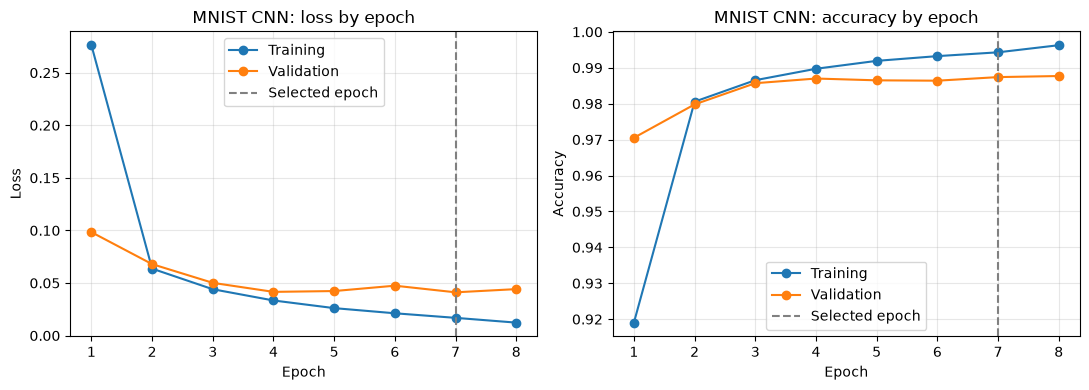

In [10]:
def plot_history(history, best_epoch, title):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ['loss', 'accuracy']):
        ax.plot(epochs, history['train_' + metric], marker='o', label='Training')
        ax.plot(epochs, history['val_' + metric], marker='o', label='Validation')
        ax.axvline(best_epoch, color='gray', linestyle='--', label='Selected epoch')
        ax.set(xlabel='Epoch', ylabel=metric.capitalize(), title=f'{title}: {metric} by epoch')
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(mnist_history, mnist_best_epoch, 'MNIST CNN')

## 1.6 Final evaluation on the untouched test set

We use the test set only now, after training is finished. Besides loss and accuracy:

- **Precision** for a digit: when the model predicts this digit, how often is it right?
- **Recall** for a digit: of all real examples of this digit, how many did the model find?
- **F1-score**: combines precision and recall into one number.
- **Support**: the number of test examples of that digit.
- **Balanced accuracy**: the average recall across classes, which matters when class counts differ.
- **Confusion matrix**: rows are the true classes and columns the predictions. Correct predictions lie on the diagonal; everything off the diagonal is a mistake.

Softmax is applied here only to show scores as probabilities. They are the model's scores, not guaranteed or calibrated confidence levels.

These helper functions are reused in Problem 2.

MNIST CNN | test loss 0.0305 | test accuracy 99.01% | balanced accuracy 99.00%
              precision    recall  f1-score   support

           0      0.994     0.992     0.993       980
           1      0.996     0.996     0.996      1135
           2      0.993     0.989     0.991      1032
           3      0.977     0.999     0.988      1010
           4      0.989     0.990     0.989       982
           5      0.991     0.985     0.988       892
           6      0.991     0.992     0.991       958
           7      0.991     0.989     0.990      1028
           8      0.995     0.982     0.988       974
           9      0.984     0.986     0.985      1009

    accuracy                          0.990     10000
   macro avg      0.990     0.990     0.990     10000
weighted avg      0.990     0.990     0.990     10000



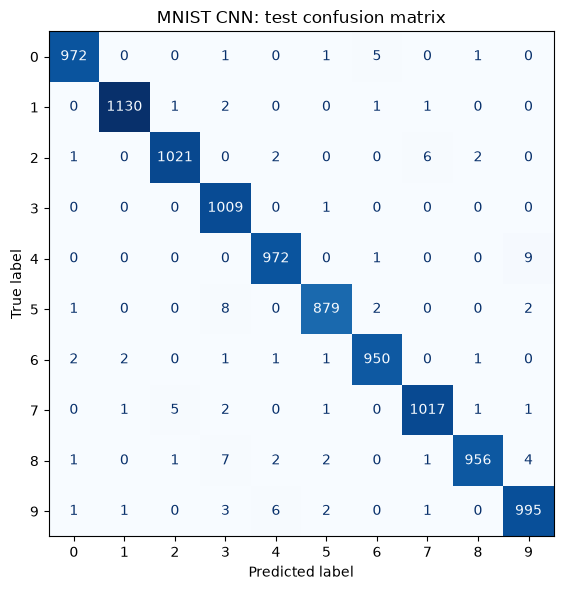

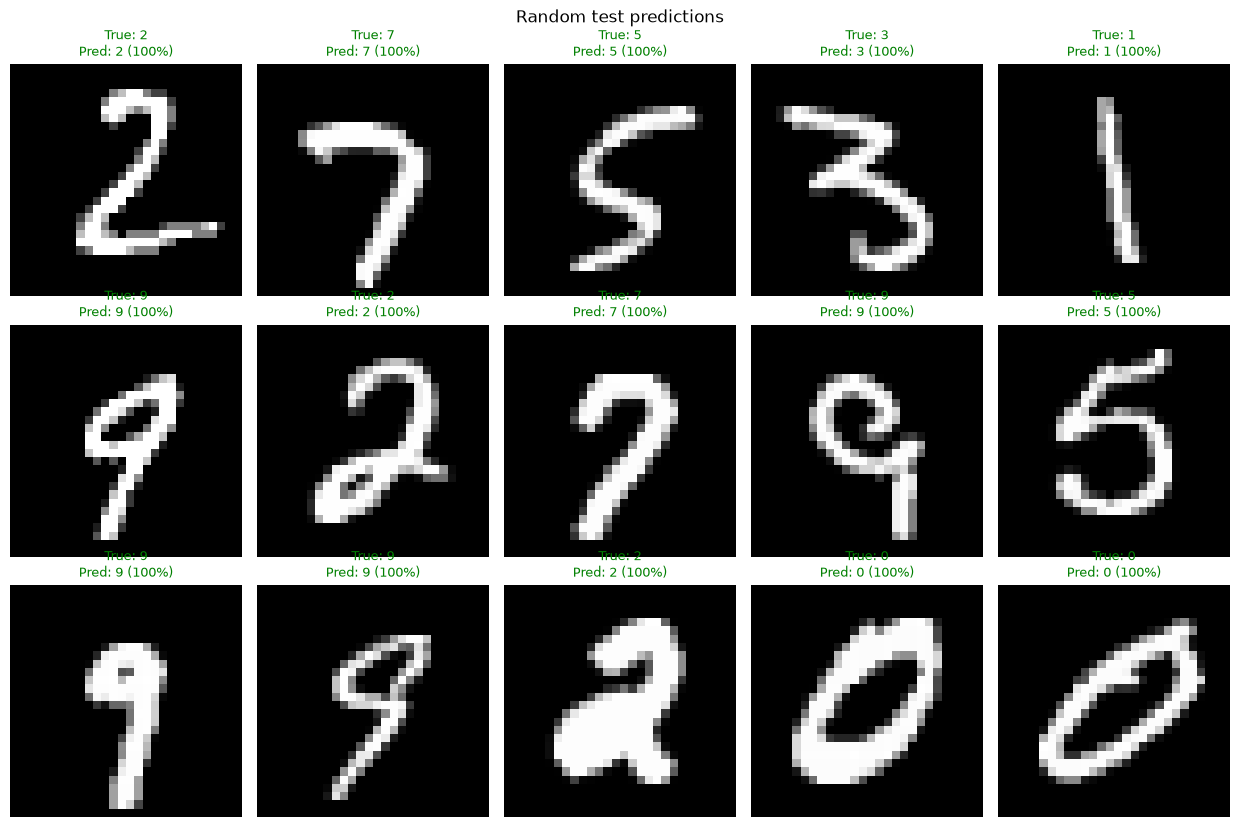

Mistakes: 99 of 10000


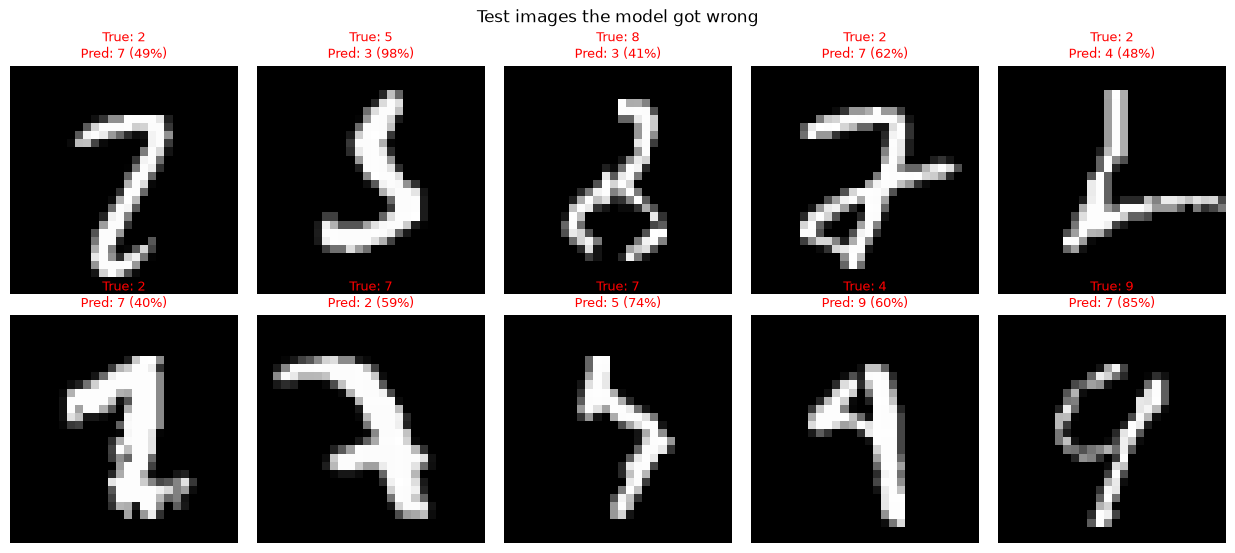

Saved weights to outputs\mnist_cnn.pth


In [11]:
def predict_loader(model, loader):
    """Return true labels, predicted labels and softmax scores for a whole DataLoader."""
    model.eval()
    trues, preds, probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            logits = model(inputs.to(device))
            probs.append(logits.softmax(1).cpu())
            preds.append(logits.argmax(1).cpu())
            trues.append(labels.cpu())
    return torch.cat(trues).numpy(), torch.cat(preds).numpy(), torch.cat(probs).numpy()


def test_report(model, loader, names, title, show_matrix=True):
    """Print test loss/accuracy/balanced accuracy + classification report; draw a confusion matrix."""
    test_loss, test_accuracy = evaluate(model, loader, nn.CrossEntropyLoss())
    y_true, y_pred, probs = predict_loader(model, loader)
    print(f'{title} | test loss {test_loss:.4f} | test accuracy {test_accuracy:.2%} '
          f'| balanced accuracy {balanced_accuracy_score(y_true, y_pred):.2%}')
    print(classification_report(y_true, y_pred, labels=list(range(len(names))),
                                target_names=[str(n) for n in names], digits=3, zero_division=0))
    if show_matrix:
        fig, ax = plt.subplots(figsize=(7, 6))
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=list(range(len(names))),
                                                display_labels=names, cmap='Blues', colorbar=False, ax=ax)
        ax.set_title(f'{title}: test confusion matrix')
        plt.tight_layout()
        plt.show()
    return y_true, y_pred, probs, test_loss, test_accuracy


def show_prediction_grid(dataset, indices, y_true, y_pred, probs, names, title, gray=False, cols=5):
    """Show images with 'True / Pred (score)'; green = correct, red = mistake."""
    if len(indices) == 0:
        print('No examples to show.')
        return
    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.8 * rows), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    for ax, i in zip(axes.flat, indices):
        image, _ = dataset[int(i)]
        ax.imshow(image[0], cmap='gray') if gray else ax.imshow(image.permute(1, 2, 0))  # C,H,W -> H,W,C
        correct = y_true[i] == y_pred[i]
        ax.set_title(f'True: {names[y_true[i]]}\nPred: {names[y_pred[i]]} ({probs[i, y_pred[i]]:.0%})',
                     color='green' if correct else 'red', fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


mnist_y_true, mnist_y_pred, mnist_probs, _, mnist_test_acc = test_report(
    mnist_model, mnist_test_loader, mnist_classes, 'MNIST CNN')

rng = np.random.default_rng(SEED)
show_prediction_grid(mnist_test, rng.choice(len(mnist_test), 15, replace=False),
                     mnist_y_true, mnist_y_pred, mnist_probs, mnist_classes,
                     'Random test predictions', gray=True)
mnist_errors = np.flatnonzero(mnist_y_true != mnist_y_pred)
print(f'Mistakes: {len(mnist_errors)} of {len(mnist_y_true)}')
show_prediction_grid(mnist_test, mnist_errors[:10], mnist_y_true, mnist_y_pred, mnist_probs,
                     mnist_classes, 'Test images the model got wrong', gray=True)

torch.save(mnist_model.state_dict(), OUTPUT_DIR / 'mnist_cnn.pth')
print('Saved weights to', OUTPUT_DIR / 'mnist_cnn.pth')

### Observations on MNIST

- The best weights came from epoch **[fill in]**. Validation accuracy **[fill in]**%, test accuracy **[fill in]**%.
- Training and validation curves **[fill in: stay close together / start to diverge after epoch N]**, so **[fill in: there is no meaningful overfitting / slight overfitting, which the best-epoch checkpoint and early stopping handled]**.
- The most frequent confusions in the matrix are **[fill in, e.g. 4→9, 7→2, 5→3]**. These digits share strokes, and the misclassified examples shown above are mostly unusual or ambiguous handwriting.
- Compared with the 8×8 sklearn digits (about 96–97% in class), the 28×28 images carry more detail, and the CNN reaches **[fill in]**%.

## 1.7 Inference on digits written in my own handwriting

I wrote **[fill in: N]** digits in thick black marker on white paper (or drew them on a square canvas) and saved each one as `my_digits/<digit>.png`, for example `my_digits/7.png`. The first character of the file name is the true label. Here we **only run inference**: the trained model is not changed.

**Why preprocessing matters.** The model only knows images that look like MNIST, so my photos have to be converted into that format:

| MNIST image | My raw photo | Preprocessing step |
|---|---|---|
| grayscale | color | convert to grayscale (`'L'`) |
| **white** digit on **black** | dark ink on white paper | invert |
| clean background | paper texture, shadows | threshold: pixels > 100 → 255, else 0 |
| digit fits in a ~20×20 box | digit fills a big photo | crop to the digit, shrink the longest side to 20 px (aspect ratio kept) |
| 28×28, digit centered | any size | paste centered on a black 28×28 canvas |
| values 0–1, shape (1, 1, 28, 28) | — | `ToTensor()` + `unsqueeze(0)` for the batch axis |

`exif_transpose` fixes phone photos that are stored rotated. An optional `MaxFilter` thickens thin strokes, which can otherwise shrink to one faint pixel at 28×28.

In [12]:
MY_DIGITS_DIR = Path('my_digits')

def prepare_my_digit(path, threshold=100, thicken=False):
    """Convert a photo/drawing of one digit into an MNIST-style (1, 1, 28, 28) tensor."""
    with Image.open(path) as photo:
        img = ImageOps.exif_transpose(photo).convert('L')        # upright + grayscale
    img = ImageOps.invert(img)                                    # white digit on black, like MNIST
    img = img.point(lambda p: 255 if p > threshold else 0)       # remove paper texture/shadows
    if thicken:
        img = img.filter(ImageFilter.MaxFilter(5))                # optional: thicker strokes
    bbox = img.getbbox()                                          # tight box around white pixels
    if bbox is None:
        raise ValueError(f'No digit found in {path.name}; try a lower threshold.')
    img = img.crop(bbox)
    img.thumbnail((20, 20), Image.LANCZOS)                        # longest side = 20 px
    canvas = Image.new('L', (28, 28), 0)                          # black 28×28 background
    canvas.paste(img, ((28 - img.width) // 2, (28 - img.height) // 2))
    return transforms.ToTensor()(canvas).unsqueeze(0)             # (1, 1, 28, 28), values 0–1

my_paths = sorted(p for p in MY_DIGITS_DIR.glob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg'})
assert my_paths, f'Put your digit images in {MY_DIGITS_DIR.resolve()}'

mnist_model.eval()
rows = []
fig, axes = plt.subplots(2, len(my_paths), figsize=(2.2 * len(my_paths), 4.8), squeeze=False)
for col, path in enumerate(my_paths):
    x = prepare_my_digit(path)
    with torch.no_grad():
        probs = mnist_model(x.to(device)).softmax(1)[0].cpu()
    predicted = probs.argmax().item()
    actual = int(path.stem[0])
    rows.append({'file': path.name, 'true': actual, 'predicted': predicted,
                 'score': round(probs[predicted].item(), 3), 'correct': actual == predicted})

    with Image.open(path) as photo:
        axes[0, col].imshow(ImageOps.exif_transpose(photo).convert('L'), cmap='gray')
    axes[0, col].set_title(f'My image: {path.name}', fontsize=8)
    axes[1, col].imshow(x[0, 0], cmap='gray')
    axes[1, col].set_title(f'True {actual} | Pred {predicted}\n{probs[predicted]:.0%}',
                           color='green' if actual == predicted else 'red', fontsize=9)
    for r in (0, 1):
        axes[r, col].axis('off')
plt.suptitle('Top: my raw images   |   Bottom: MNIST-style input the model receives')
plt.tight_layout()
plt.show()

my_results = pd.DataFrame(rows)
print(my_results.to_string(index=False))
print(f'\nCorrect on my handwriting: {my_results.correct.sum()} of {len(my_results)}')

AssertionError: Put your digit images in C:\Users\cafe\CSCI89\Assignment4\my_digits